In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

pd.set_option('display.float_format', '{:.5e}'.format)

In [3]:
plt.style.use("style.mplstyle")
#plt.style.use('default')

# General graphing functions

In [4]:
def label_axes(fig, loc, labels=None, extra_lab=None , **kwargs):
    import string
    
    if labels is None:
        labels=string.ascii_lowercase

    if extra_lab==None:
        for ax, lab in zip(fig.axes, labels):
            ax.annotate("("+lab+")",xy=loc,xycoords="axes fraction",**kwargs)
    else:
        for ax, lab, el in zip(fig.axes, labels,extra_lab):
            ax.annotate("("+lab+")"+el,xy=loc,xycoords="axes fraction",**kwargs)

In [5]:
def generate_colormap(n, palette_type="continuous",palette="rainbow"):
    """
    Generate a colormap depending on dataset size.

    Parameters
    ----------
    n : int
        Number of distinct values in the dataset
    palette_type : str
        'auto', 'categorical', or 'continuous'

    Returns
    -------
    list of colors (RGBA tuples)
    """

    if n <= 0:
        raise ValueError("n must be a positive integer")

    # Auto mode: choose based on size
    if palette_type == "auto":
        if n <= 20:
            palette_type = "categorical"
        else:
            palette_type = "continuous"

    if palette_type == "categorical":
        # Use high-quality categorical palettes
        base_cmaps = ["tab10", "tab20", "Set3"]
        cmap_name = base_cmaps[min(len(base_cmaps) - 1, n // 10)]
        cmap = plt.get_cmap(cmap_name)
        colors = [cmap(i % cmap.N) for i in range(n)]

    elif palette_type == "continuous":
        # Perceptually uniform colormap
        cmap = plt.get_cmap(palette)
        colors = [cmap(i) for i in np.linspace(0, 1, n)]

    else:
        raise ValueError("palette_type must be 'auto', 'categorical', or 'continuous'")

    return colors

In [6]:
class BoundedMinorLocator(ticker.Locator):
    """Place minor ticks at fixed intervals, but only up to `cutoff`."""
    def __init__(self, step, cutoff):
        self.step = step
        self.cutoff = cutoff

    def __call__(self):
        vmin, vmax = self.axis.get_view_interval()
        upper = min(vmax, self.cutoff)
        ticks = np.arange(
            np.ceil(vmin / self.step) * self.step,
            upper + 1e-9,
            self.step,
        )
        return self.raise_if_exceeds(ticks)

In [7]:
from scipy.optimize import curve_fit
from scipy.stats import pearsonr
    
def fit_curvefit(datax, datay, fit_func, p0, yerr=None, **kwargs):
        
    pfit, pcov = curve_fit(fit_func,datax,datay,p0=p0, sigma=yerr, absolute_sigma=True, **kwargs)
    error = [] 
    for i in range(len(pfit)):
        try:
          error.append(np.absolute(pcov[i][i])**0.5)
        except:
          error.append( 0.00 )

    r2 = pearsonr(datax, datay).statistic**2
    
    return pfit, np.array(error), r2

# Set up

In [8]:
width,height=plt.rcParams["figure.figsize"]
cmap_eta=generate_colormap(9,"continuous","brg")

# Lyapunov vector components

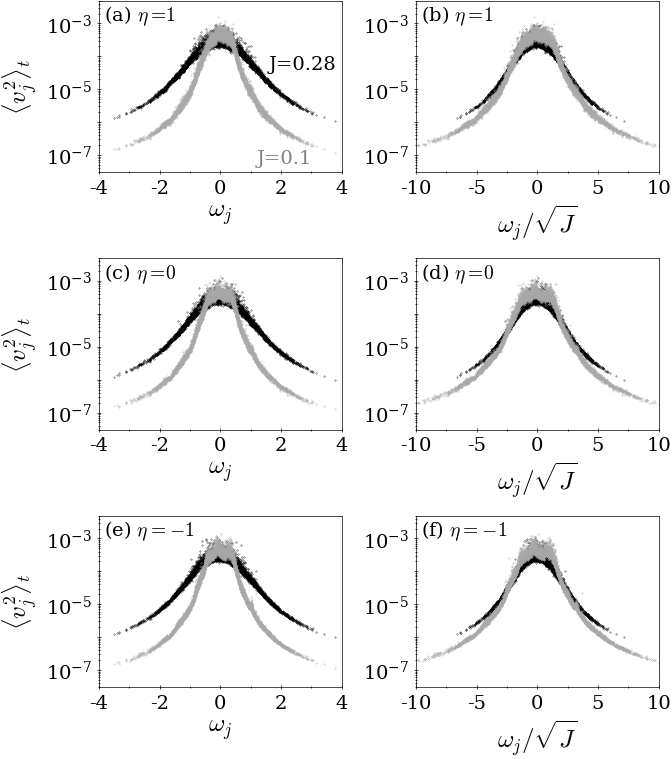

In [9]:
J_list=["0.28","0.1"]
eta_list=["1","0","-1"]
N=6400

cmap=["k","darkgray"]
fig,axs=plt.subplots(3,2,figsize=(width*2,height*3),dpi=100)
for ei in range(len(eta_list)):
    axs_e=axs[ei,:]
    for Ji in range(len(J_list)):
        J=J_list[Ji]
        e=eta_list[ei]

        freq, v2 = np.loadtxt(f"data/figsData/LyapVec/LyapVec_N{N}_J{J}_e{e}.txt", delimiter=' ', unpack=True)
        
        axs_e[1].plot(freq/np.sqrt(float(J)),v2,".",color=cmap[Ji],markersize=0.5)
        axs_e[0].plot(freq,v2,".",markersize=0.5,color=cmap[Ji])
    
    axs_e[1].set_yscale("log")
    axs_e[1].set_xlabel("$\omega_j/\sqrt{J}$")
    axs_e[1].set_xlim(-10,10)
    axs_e[1].set_ylim(3e-8,5e-3)
    
    axs_e[1].xaxis.set_major_locator(ticker.MultipleLocator(5))
    axs_e[1].xaxis.set_major_formatter('{x:.0f}')
    axs_e[1].xaxis.set_minor_locator(ticker.MultipleLocator(2.5))

    axs_e[1].yaxis.set_ticks([10**x for x in range(-7,-2)])
    axs_e[1].yaxis.set_ticklabels(["$\mathregular{10^{-7}}$","","$\mathregular{10^{-5}}$","","$\mathregular{10^{-3}}$"])
    axs_e[1].yaxis.set_minor_locator(ticker.LogLocator(numticks=999,subs="auto"))

    
    axs_e[0].set_yscale("log")
    axs_e[0].set_xlabel("$\omega_j$")
    axs_e[0].set_xlim(-4,4)
    axs_e[0].set_ylim(3e-8,5e-3)
    
    axs_e[0].xaxis.set_major_locator(ticker.MultipleLocator(2))
    axs_e[0].xaxis.set_major_formatter('{x:.0f}')
    axs_e[0].xaxis.set_minor_locator(ticker.MultipleLocator(1))
    
    axs_e[0].yaxis.set_ticks([10**x for x in range(-7,-2)])
    axs_e[0].yaxis.set_ticklabels(["$\mathregular{10^{-7}}$","","$\mathregular{10^{-5}}$","","$\mathregular{10^{-3}}$"])
    axs_e[0].yaxis.set_minor_locator(ticker.LogLocator(subs="auto",numticks=999))
    
    
    axs_e[0].set_ylabel("$\langle v_j^2\\rangle_t$")

for ax in axs.flatten():
    ax.tick_params(axis='both', which='both', direction="inout")
label_axes(fig, (0.02,0.88), extra_lab=[f" $\eta=\!{x}$" for x in ["1","1","0","0","-\!1","-\!1"]],fontsize=14)
fig.tight_layout()

axs[0,0].annotate("J=0.28",xy=(0.7,0.6),xycoords="axes fraction",color="k",fontsize=14)
axs[0,0].annotate("J=0.1",xy=(0.65,0.05),xycoords="axes fraction",color="gray",fontsize=14)

#plt.savefig("Figs/LyapVec.eps",bbox_inches="tight")
plt.show()

# Lyapunov Exponent vs J

## Normal distribution

In [10]:
normal_df=pd.read_csv("data/figsData/LE_J_distrNormal.csv")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


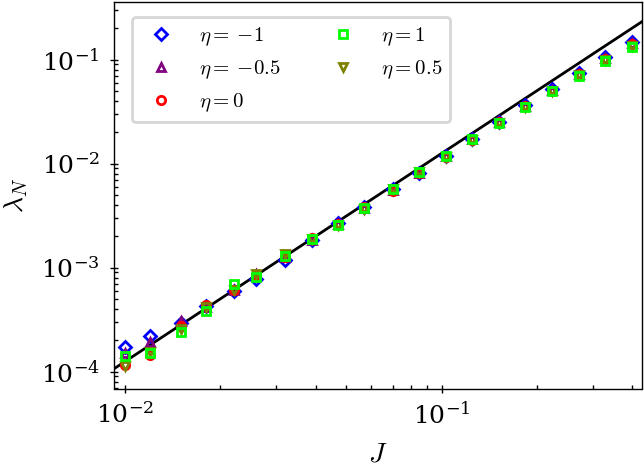

In [11]:
J_list=normal_df["J"].unique()
eta_list=normal_df["eta"].unique()
xrange=np.geomspace(J_list[0]*0.9,J_list[-1]*1.1,num=1000)
markers=["D","^","o","v","s"]

fig,ax=plt.subplots()

ax.plot(xrange,np.sqrt(np.pi/2)*(xrange**2),color="k",zorder=-10)

for ei in range(0,len(eta_list)):
    tempdf=normal_df[normal_df["eta"]==eta_list[ei]]
    ax.plot(J_list, tempdf["lambda"],marker=markers[ei],label="A",
                color=cmap_eta[ei*2],fillstyle="none",linestyle="none")

plt.xlim(9.2e-3,0.43)
#plt.ylim(1e-4,1.5e-1)
ax.set_xlabel("$J$",fontsize=10)
ax.set_ylabel("$\\lambda_{N}$",fontsize=10)
ax.set_xscale("log")
ax.set_yscale("log")
ax.tick_params(axis='both', which='major', labelsize=9, direction="inout")

handles,_=ax.get_legend_handles_labels()
eta_label=["-\!1","-\!0.5","0","1","0.5"]
fig.legend([handles[i] for i in [0,1,2,4,3]],[f"$\eta={e}$" for e in eta_label],loc=(0.205,0.74),ncols=2,fontsize=7.5)
#fig.legend([handles[i] for i in [0,1,2,4,3]],[f"$\eta={e}$" for e in eta_label],loc=(0.49,0.22),ncols=2,fontsize=7.5)
fig.tight_layout()
#plt.savefig("Figs/figNormal.eps",bbox_inches='tight')
plt.show()

## Uniform distribution

In [14]:
uniform_df=pd.read_csv("data/figsData/LE_J_distrUniform.csv")

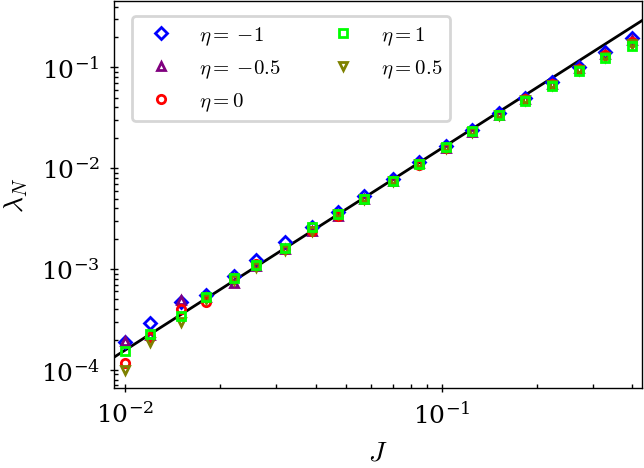

In [16]:
J_list=uniform_df["J"].unique()
eta_list=uniform_df["eta"].unique()
xrange=np.geomspace(J_list[0]*0.9,J_list[-1]*1.1,num=1000)
markers=["D","^","o","v","s"]

fig,ax=plt.subplots()

ax.plot(xrange,np.pi*(xrange**2)/2,color="k",zorder=-10)

for ei in range(0,len(eta_list)):
    tempdf=uniform_df[uniform_df["eta"]==eta_list[ei]]
    ax.plot(J_list, tempdf["lambda"],marker=markers[ei],label="A",
                color=cmap_eta[ei*2],fillstyle="none",linestyle="none")

plt.xlim(9.2e-3,0.43)
#plt.ylim(1e-4,1.5e-1)
ax.set_xlabel("$J$",fontsize=10)
ax.set_ylabel("$\\lambda_N$",fontsize=10)
ax.set_xscale("log")
ax.set_yscale("log")
ax.tick_params(axis='both', which='major', labelsize=9, direction="inout")

handles,_=ax.get_legend_handles_labels()
eta_label=["-\!1","-\!0.5","0","1","0.5"]
fig.legend([handles[i] for i in [0,1,2,4,3]],[f"$\eta={e}$" for e in eta_label],loc=(0.205,0.74),ncols=2,fontsize=7.5)
fig.tight_layout()
#plt.savefig("Figs/figUniform.eps",bbox_inches='tight')
plt.show()

# Lyapunov Exponent $[\lambda_N]$ vs Asymmetry $\eta$

In [12]:
pfits=np.load("data/fitsLE_inf.npz")
alpha=pfits["alpha"]
lnk=pfits["ln_k"]

In [13]:
mean_pd=pd.read_csv("data/rawData/avLE_sim.csv")
linf_pd=pd.read_csv("data/rawData/LEinf_mean.csv")

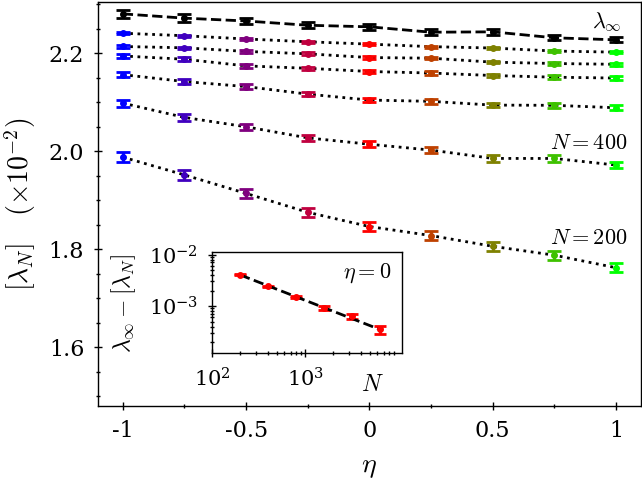

In [15]:
J=0.14 #Index 0 in pfits
df_J=mean_pd[mean_pd["J"]==J]
N_list=df_J["N"].unique()
eta_list=df_J["eta"].unique()

idx_eta_inset=4

fig, ax=plt.subplots()
axins=ax.inset_axes([0.21,0.13,0.35,0.25])#,xlim=(x1,x2),ylim=(y1,y2))

for Ni in range(len(N_list)):
    tempN=df_J[df_J["N"]==N_list[Ni]]
    ax.plot(tempN["eta"],tempN["lambda"]*1e2,color="k",marker="none",linestyle=":")

linf=linf_pd[linf_pd["J"]==J]["linf_opt"]
linf_err=linf_pd[linf_pd["J"]==J]["err_linf_opt"]

ax.errorbar(eta_list,linf*1e2,yerr=linf_err*1e2,color="k",marker=".",capsize=2.5,fmt="--")

for ei in range(len(eta_list)):

    tempN=df_J[df_J["eta"]==eta_list[ei]]
    ax.errorbar(tempN["eta"],tempN["lambda"]*1e2,yerr=tempN["err_lambda"]*1e2,capsize=2.5,color=cmap_eta[ei],marker=".",linestyle="none")

    if ei==idx_eta_inset:
        l_N=df_J[df_J["eta"]==eta_list[ei]][["lambda","err_lambda"]].to_numpy()

        x_obs_inset=np.log(N_list)
        y_obs_inset=np.log(linf[ei]-l_N[:,0])
        
        expy_err=np.sqrt(linf_err[ei]**2+l_N[:,1]**2)
        y_obs_err=expy_err/np.abs(linf[ei]-l_N[:,0])
        
        xreg=np.linspace(x_obs_inset[0],x_obs_inset[-1])
        yreg=lnk[0,ei,0]-alpha[0,ei,0]*xreg
        
        axins.errorbar(np.exp(x_obs_inset),np.exp(y_obs_inset),yerr=expy_err,marker=".",linestyle="none",capsize=2,color=cmap_eta[ei])
        axins.plot(np.exp(xreg),np.exp(yreg),"k--")

axins.set_xscale("log")
axins.set_yscale("log")
axins.set_ylim(1.2e-4,1.1e-2)
axins.yaxis.set_ticks([1e-3,1e-2])
axins.yaxis.set_ticklabels(["$\mathregular{10^{-3}}$","$\mathregular{10^{-2}}$"])
axins.set_xlim(1e2,1.1e4)
axins.xaxis.set_ticks([1e2,1e3])
axins.xaxis.set_ticklabels(["$\mathregular{10^{2}}$","$\mathregular{10^{3}}$"],)
axins.set_ylabel("$\lambda_{\infty}-[\lambda_N]$",fontsize=8.5)
fig.text(0.475,0.355,"$\eta=0$",fontsize=8)

fig.text(0.5,0.14,"$N$",fontsize=8.5)
axins.tick_params(which="both",axis='both',labelsize=7.5,direction="inout")

ax.set_ylabel("$[\lambda_N]$   $(\\times 10^{-2})$",fontsize=10)
ax.set_xlabel("$\eta$",fontsize=10)
ax.set_ylim(1.48,2.305)
ax.xaxis.set_ticks([-1,-0.5,0,0.5,1])
ax.xaxis.set_ticklabels(["-1","-0.5","0","0.5","1"])
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.05))
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax.tick_params(which="both",axis='both',labelsize=8,direction="inout")

fig.text(0.77,0.42,"$N=200$",fontsize=8)
fig.text(0.77,0.6,"$N=400$",fontsize=8)
fig.text(0.83,0.83,"$\lambda_{\infty}$",fontsize=8)

ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0),useMathText=False)

#plt.tight_layout()
#plt.savefig("Figs/lyap_Asym_J014.eps",bbox_inches='tight')
plt.show()

## Parameters

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


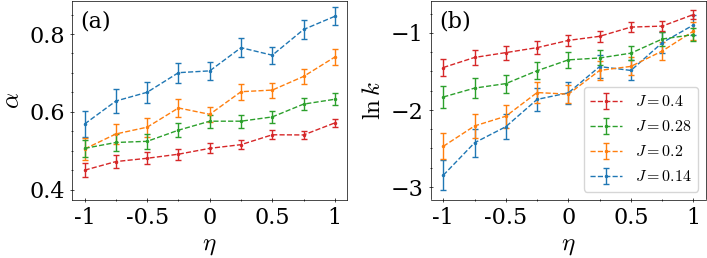

In [19]:
J_list=[0.14,0.2,0.28,0.4]

fig,axs=plt.subplots(1, 2,sharex=True,figsize=(width*2.1,height*1.09),dpi=100)
eta_list=mean_pd["eta"].unique()

for Ji in range(len(J_list)):
    J=J_list[Ji]
    
    axs[0].errorbar(eta_list,alpha[Ji,:,0],yerr=alpha[Ji,:,1],capsize=2.5,fmt=".--",label=f"$J={J_list[Ji]}$")
    axs[1].errorbar(eta_list,lnk[Ji,:,0],yerr=lnk[Ji,:,1],capsize=2.5,fmt=".--",label=f"$J={J_list[Ji]}$")


axs[1].set_ylabel("$\ln k$",fontsize=18)
axs[0].set_ylabel("$\\alpha$",fontsize=18)

axs[0].yaxis.set_ticks([0.4,0.6,0.8])
axs[0].yaxis.set_ticklabels(["0.4","0.6","0.8"])
axs[0].set_ylim(0.375,0.885)

#axs[1].legend(ncols=1,fontsize=11.5)
axs[0].yaxis.set_minor_locator(ticker.MultipleLocator(0.05))
#axs[0].yaxis.set_major_locator(ticker.MultipleLocator(0.1))
axs[1].yaxis.set_minor_locator(ticker.MultipleLocator(0.25))
#axs[1].yaxis.set_major_locator(ticker.MultipleLocator(0.5))

for ax in axs:
    ax.set_xlabel("$\eta$",fontsize=18)
    ax.xaxis.set_ticks([-1,-0.5,0,0.5,1])
    ax.xaxis.set_ticklabels(["-1","-0.5","0","0.5","1"])
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))
    
    ax.tick_params(which="both",axis='both',labelsize=16,direction="inout")
    
fig.tight_layout()
label_axes(fig, (0.03,0.865),fontsize=16)

handles,_=axs[1].get_legend_handles_labels()
axs[1].legend(handles=[handles[i] for i in reversed(range(len(handles)))],ncols=1,fontsize=11.5)

#plt.savefig("Figs/coef_Reg_linf.eps",bbox_inches='tight')
plt.show()

# Lyapunov Exponent Scaling

In [13]:
pfits=np.load("data/fitsWeak.npz")
a=pfits["a"]
b=pfits["b"]

In [14]:
linf_pd=pd.read_csv("data/rawData/LEinf_mean.csv")

b_0	=	0.8715246516624697	+-	0.009457797081247995
b_1	=	0.15550216051445676	+-	0.014120515460372423
R^2	=	0.9963833378165968


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


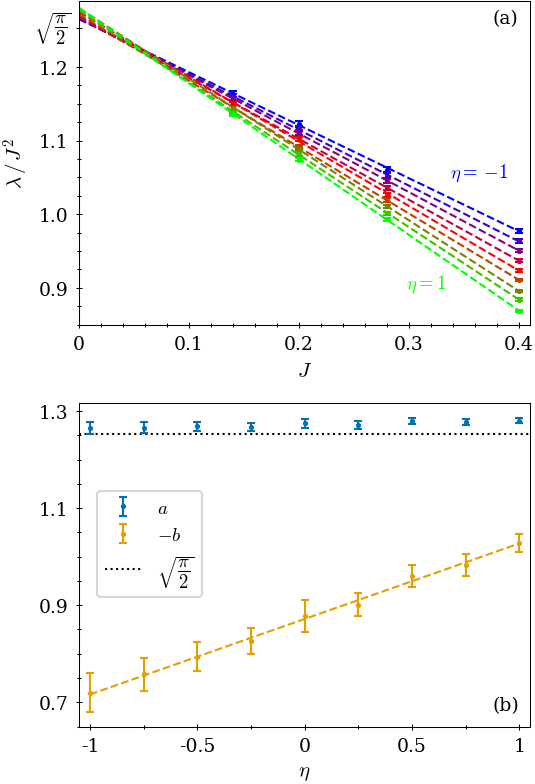

In [15]:
fig,axs=plt.subplots(2, 1,figsize=(width*1.1,height*2.1),dpi=150)

ax=axs[0]

J_list=np.array([0.14,0.2,0.28,0.4])
eta_list=linf_pd["eta"].unique()

Jrange=np.linspace(0,J_list[-1])

for ei in range(len(eta_list)):
    
    ydata=linf_pd[(linf_pd["eta"]==eta_list[ei]) & (linf_pd["J"].isin(J_list))]["linf_opt"]/J_list**2
    err_ydata=linf_pd[(linf_pd["eta"]==eta_list[ei]) & (linf_pd["J"].isin(J_list))]["err_linf_opt"]/J_list**2
    
    ax.errorbar(J_list, ydata, yerr=err_ydata, color=cmap_eta[ei],capsize=2,fmt=".",label=f"$\\eta={eta_list[ei]}$")
    ax.plot(Jrange,a[ei,0]+b[ei,0]*Jrange,"--",color=cmap_eta[ei])
    
#plt.axhline(np.sqrt(np.pi/2),color="k",alpha=0.5)

ax.set_xlabel("$J$",fontsize=10)
#plt.ylabel("$\dfrac{\\lambda}{J^2}$",fontsize=10)
ax.set_ylabel("$\lambda\,/\,J^2$",fontsize=10)
#plt.legend(ncols=2,loc="upper right",fontsize=7)

ax.yaxis.set_ticks([np.sqrt(np.pi/2),1.2,1.1,1,0.9])
ax.yaxis.set_ticklabels(["","1.2","1.1","1.0","0.9"])
fig.text(0.095,0.935,"$\sqrt{\\dfrac{\pi}{2}}$",fontsize=9)

#ax.yaxis.set_ticks([np.sqrt(np.pi/2),np.sqrt(np.pi/2)+0.01,1.2,1.1,1,0.9])
#ax.yaxis.set_ticklabels(["","$\sqrt{\\frac{\pi}{2}}$","$1.2$","$1.1$","$1.0$","$0.9$"])

ax.yaxis.set_minor_locator(BoundedMinorLocator(0.025, cutoff=1.2))

ax.xaxis.set_ticks([0,0.1,0.2,0.3,0.4])
ax.xaxis.set_ticklabels(["0","0.1","0.2","0.3","0.4"])
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.02))

ax.tick_params(which="both",axis='both',labelsize=9,direction="inout")

fig.text(0.74,0.625,"$\eta=1$",fontsize=9,color=cmap_eta[-1])
fig.text(0.815,0.76,"$\eta=-\!1$",fontsize=9,color=cmap_eta[0])
fig.text(0.89,0.945,"(a)",fontsize=9)
ax.set_ylim(0.85,1.29)
ax.set_xlim(0,0.41)

ax=axs[1]

ax.errorbar(eta_list,a[:,0],yerr=a[:,1],capsize=2,label="$a$",marker=".",linestyle="none",color='#0072B2')
ax.errorbar(eta_list,-b[:,0],yerr=b[:,1],capsize=2,label="$-b$",marker=".",linestyle="none",color='#E69F00')

pfit,perr,r=fit_curvefit(eta_list, -b[:,0], lambda x,p0,p1: p0+p1*x, np.array([0,0]),yerr=b[:,1])
print(f"b_0\t=\t{pfit[0]}\t+-\t{perr[0]}")
print(f"b_1\t=\t{pfit[1]}\t+-\t{perr[1]}")
print(f"R^2\t=\t{r}")

plt.plot(np.linspace(eta_list[0],eta_list[-1]),pfit[0]+pfit[1]*np.linspace(eta_list[0],eta_list[-1]),"--",color='#E69F00')

ax.xaxis.set_ticks([-1,-0.5,0,0.5,1])
ax.xaxis.set_ticklabels(["-1","-0.5","0","0.5","1"])
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.05))
ax.tick_params(which="both",axis='both',labelsize=9,direction="inout")

ax.axhline(np.sqrt(np.pi/2),color="k",linestyle=":",zorder=-10,label="$\sqrt{\\dfrac{\pi}{2}}$")
#fig.text(0.075,0.85,"$\sqrt{\pi/2}$",fontsize=7)

ax.set_xlabel("$\\eta$",fontsize=10)
#ax.set_ylabel("Scaling Coefficients",fontsize=10)

#ax.yaxis.set_ticks([1.3,1.2,1.1,1,0.9,0.8,0.7])
#ax.yaxis.set_ticklabels(["1.3","","1.1","","0.9","","0.7"])
ax.yaxis.set_ticks([1.3,1.1,0.9,0.7])
ax.yaxis.set_ticklabels(["1.3","1.1","0.9","0.7"])

#ax.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(BoundedMinorLocator(0.05, cutoff=1.3))
ax.set_xlim(-1.05,1.05)

handles,_=ax.get_legend_handles_labels()
fig.text(0.89,0.115,"(b)",fontsize=9)
ax.legend(handles=[handles[i] for i in [1,2,0]],loc=(0.04,0.4),fontsize=9)
fig.tight_layout()
#plt.savefig("Figs/Weak_linfReg_both.eps",bbox_inches="tight")
plt.show()

# Difusion

In [17]:
D_pd=pd.read_csv("data/rawData/Diffusion.csv")

	eta=1
A      =  0.19661545554540635 +/- 0.5445795666953737
gamma  =  0.6518349532976456 +/- 0.4562202270736846
R2     =  0.998188929060923

	eta=0
A      =  0.11996121133215489 +/- 0.33226497055055504
gamma  =  0.6032686755190497 +/- 0.4562202661511766
R2     =  0.9988942164226277

	eta=-1
A      =  0.06409968976229573 +/- 0.17754138178922904
gamma  =  0.5289667080181746 +/- 0.456220219559743
R2     =  0.997293517787321



The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


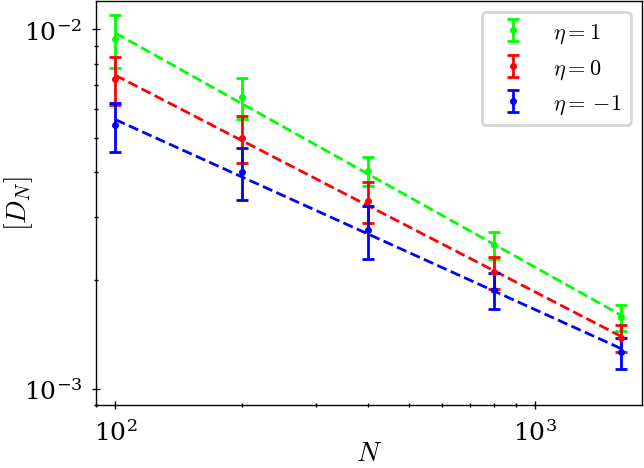

In [18]:
cmap=[cmap_eta[i] for i in [0,4,-1]]

fig,ax=plt.subplots()

eta_list=D_pd["eta"].unique()
N_list=D_pd["N"].unique()

for ei in reversed(range(len(eta_list))):
    print(f"\teta={eta_list[ei]}")
    
    Deta=D_pd[D_pd["eta"]==eta_list[ei]]
    ax.errorbar(N_list,Deta["D"],yerr=Deta["err_D"],capsize=2,marker=".",linestyle="none",color=cmap[ei],label=f"$\eta={eta_list[ei]}$")
    
    x_obs=np.log(N_list)
    y_obs=np.log(Deta["D"])
    
    pfit, perr, r2 = fit_curvefit(x_obs, y_obs, lambda x,p0,p1: p0+p1*x, np.array([1,1]),None)

    print(f"A      =  {np.exp(pfit[0])} +/- {np.abs(perr[0]*np.exp(pfit[0]))}")
    print(f"gamma  =  {-pfit[1]} +/- {perr[1]}")
    print(f"R2     =  {r2}\n")

    ax.plot(np.linspace(N_list[0],N_list[-1]), np.exp(pfit[0])*(np.linspace(N_list[0],N_list[-1])**pfit[1]),color=cmap[ei],linestyle="--")

ax.set_ylim(0.9e-3,1.2e-2)
ax.set_xlim(0.9e2,1.8e3)
ax.tick_params(which="both",axis='both',labelsize=9,direction="inout")
ax.set_ylabel("$[D_N]$",fontsize=10,labelpad=-4)
ax.set_xlabel("$N$",fontsize=10,labelpad=-2)
ax.set_yscale("log")
ax.set_xscale("log")

handles,_=ax.get_legend_handles_labels()
eta_label=["1","0","-\!1"]
plt.legend([handles[i] for i in range(len(eta_label))],[f"$\eta={e}$" for e in eta_label],loc="upper right",fontsize=8)
fig.tight_layout()
plt.savefig("Figs/Diffusion.eps")
plt.show()